# Load data

In [1]:
import scipy.io
import numpy as np
mat = scipy.io.loadmat("Xtrain.mat")
y = mat["Xtrain"].squeeze().astype(np.float32)
print(y)

[ 86. 141.  95.  41.  22.  21.  32.  72. 138. 111.  48.  23.  19.  27.
  59. 129. 129.  58.  27.  19.  24.  46. 112. 144.  73.  30.  20.  19.
  37.  92. 152.  93.  36.  20.  18.  29.  71. 146. 117.  46.  23.  18.
  22.  52. 128. 142.  62.  26.  17.  19.  37. 100. 158.  86.  32.  17.
  17.  27.  72. 154. 118.  43.  20.  15.  21.  47. 128. 150.  63.  24.
  16.  17.  33.  92. 166.  95.  33.  16.  14.  22.  58. 149. 137.  50.
  20.  15.  16.  35. 106. 169.  82.  28.  15.  14.  23.  65. 160. 133.
  45.  18.  14.  16.  36. 111. 176.  80.  26.  14.  13.  20.  60. 163.
 140.  45.  18.  12.  14.  30.  98. 185.  93.  28.  14.  12.  17.  46.
 145. 167.  58.  19.  11.  12.  21.  68. 183. 132.  38.  15.  11.  13.
  26.  93. 202. 100.  27.  12.  10.  13.  30. 114. 206.  82.  21.  11.
   9.  10.  30. 120. 215.  77.  20.  10.   8.   9.  21.  95. 234.  99.
  22.   9.   8.   7.   9.  35. 176. 215.  46.  11.   7.   5.   4.   3.
   4.  19. 105. 125.  55.  30.  28.  41.  71.  98.  79.  49.  34.  33.
  47. 

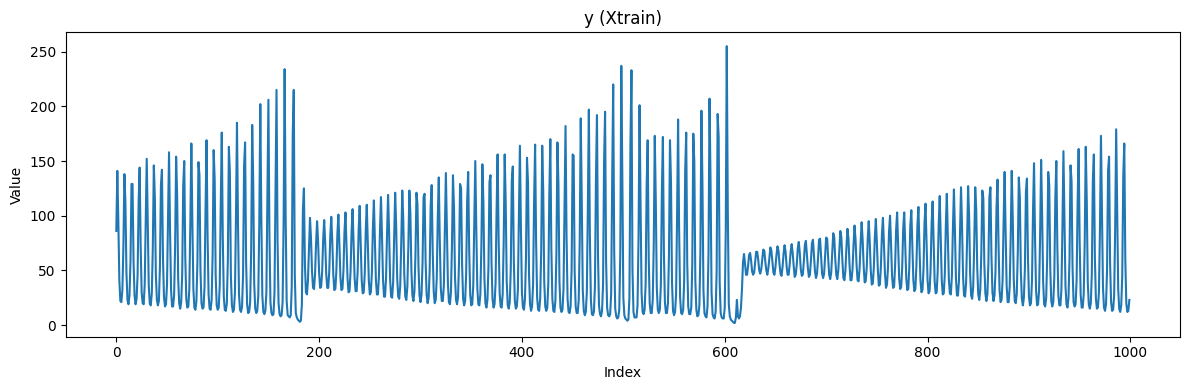

In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.plot(y)
plt.title("y (Xtrain)")
plt.xlabel("Index")
plt.ylabel("Value")
plt.tight_layout()
plt.show()

# Split data chronologically: train / tuning-validation


In [3]:
N = len(y)

train_end = int(0.80 * N)

y_train = y[:train_end]         
y_val_tune = y[train_end:]      


In [4]:
# Scale using train statistics only
mu = y_train.mean()
sigma = y_train.std()

y_train_scaled = (y_train - mu) / sigma
y_val_tune_scaled = (y_val_tune - mu) / sigma


In [5]:
def past_windows_parameter(y_scaled, p):
    X = []
    T = []

    for i in range(len(y_scaled) - p):
        X.append(y_scaled[i:i+p])
        T.append(y_scaled[i+p])

    X = np.array(X, dtype=np.float32)
    T = np.array(T, dtype=np.float32).reshape(-1, 1)

    return X, T

In [6]:
p = 10

X_train, T_train = past_windows_parameter(y_train_scaled, p)
X_val_tune, T_val_tune = past_windows_parameter(y_val_tune_scaled, p)

print("X_train:", X_train.shape)
print("T_train:", T_train.shape)
print("X_val_tune:", X_val_tune.shape)
print("T_val_tune:", T_val_tune.shape)


X_train: (790, 10)
T_train: (790, 1)
X_val_tune: (190, 10)
T_val_tune: (190, 1)


# convert to PyTorch tensors
X_train had the shape [num_samples, p] but for LSTM I need [num_samples, p, 1] so ```unsqueeze(-1)``` is added to reshape it.

In [7]:
import torch
from torch.utils.data import TensorDataset, DataLoader

torch.manual_seed(42)
np.random.seed(42)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32).unsqueeze(-1)
T_train_tensor = torch.tensor(T_train, dtype=torch.float32)

X_val_tune_tensor = torch.tensor(X_val_tune, dtype=torch.float32).unsqueeze(-1)
T_val_tune_tensor = torch.tensor(T_val_tune, dtype=torch.float32)

train_dataset = TensorDataset(X_train_tensor, T_train_tensor)
val_tune_dataset = TensorDataset(X_val_tune_tensor, T_val_tune_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_tune_dataset, batch_size=32, shuffle=False)


In [8]:
# Check if the shape is correct for LSTM input
X_batch, T_batch = next(iter(train_loader))
print(X_batch.shape) 

torch.Size([32, 10, 1])


# LSTM model
Next to the hyperparameter ```p``` <i>(# of past timesteps)</i> , I also chose to tune the ```hidden_size``` <i>(LSTM hidden state size)</i>. These values are currently set to ```p=10``` and ```hidden_size=64```, to test the working of the model before finetuning. Different values that could also be finetuned are the```num_layers``` <i>(number of stacked LSTM layers)</i> and the then relevant parameter ```dropout```, however I've omitted further tuning because it's only a small assignment.   

In [9]:
import torch.nn as nn

class LSTM(nn.Module):
    def __init__(self, hidden_size=64):
        super().__init__()

        # LSTM layer
        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=hidden_size,
            num_layers=1,
            batch_first=True
        )

        # Fully connected layer
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # Pass through LSTM
        lstm_out, _ = self.lstm(x)

        # Take the output of last timestep of the LSTM and map to prediction through FC layer: 
        # from "hidden_size" to 1, since we need a single value as prediction. 
        prediction = self.fc(lstm_out[:, -1, :])

        return prediction


model = LSTM(hidden_size=64)

print(model)

LSTM(
  (lstm): LSTM(1, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


# Train

In [16]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

n_epochs = 200
train_losses, val_losses = [], []

for epoch in range(n_epochs):
    model.train()
    batch_losses = []
    for X_batch, T_batch in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(X_batch), T_batch)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())
    train_losses.append(np.mean(batch_losses))

    model.eval()
    val_batch_losses = []
    with torch.no_grad():
        for X_batch, T_batch in val_loader:
            val_batch_losses.append(criterion(model(X_batch), T_batch).item())
    val_losses.append(np.mean(val_batch_losses))

    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1}/{n_epochs}  train={train_losses[-1]:.4f}  val={val_losses[-1]:.4f}")

Epoch 50/200  train=0.0215  val=0.0021
Epoch 100/200  train=0.0104  val=0.0017
Epoch 150/200  train=0.0082  val=0.0012
Epoch 200/200  train=0.0037  val=0.0009


# Loss curves

In [17]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="train")
plt.plot(val_losses, label="val")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.legend()
plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

# Predictions

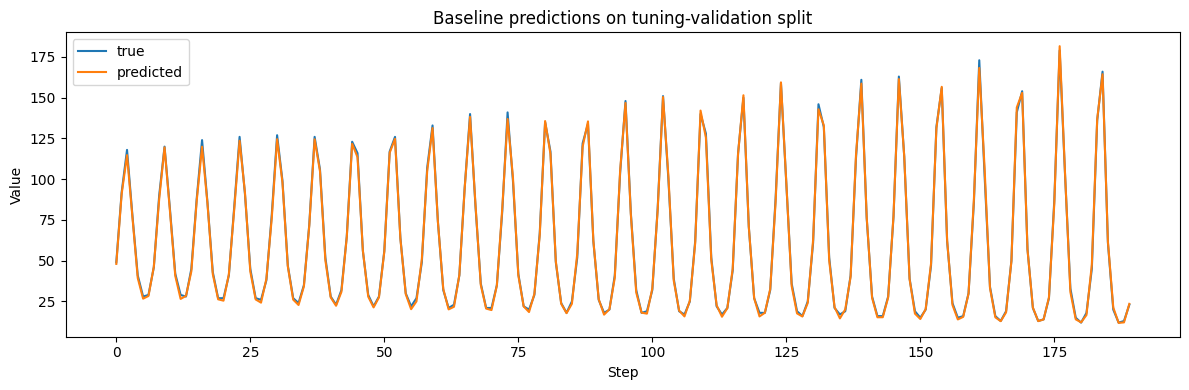

Tuning-val MSE: 1.95


In [ ]:
model.eval()
with torch.no_grad():
    y_pred_scaled = model(X_val_tune_tensor).numpy().squeeze()

y_pred = y_pred_scaled * sigma + mu
y_true = T_val_tune.squeeze() * sigma + mu

plt.figure(figsize=(12, 4))
plt.plot(y_true, label="true")
plt.plot(y_pred, label="predicted")
plt.xlabel("Step")
plt.ylabel("Value")
plt.title("Baseline predictions on tuning-validation split")
plt.legend()
plt.tight_layout()
plt.show()

mse = np.mean((y_pred - y_true) ** 2)
print(f"Tuning-val MSE: {mse:.2f}")


# Closer look at the data
This ACF (Autocorrelation function) plot basically shows the correlation of a time series with its own past values (lags). These results influence my tuning of ```p```, what sizes are more usefull then others and which ones I want to test.

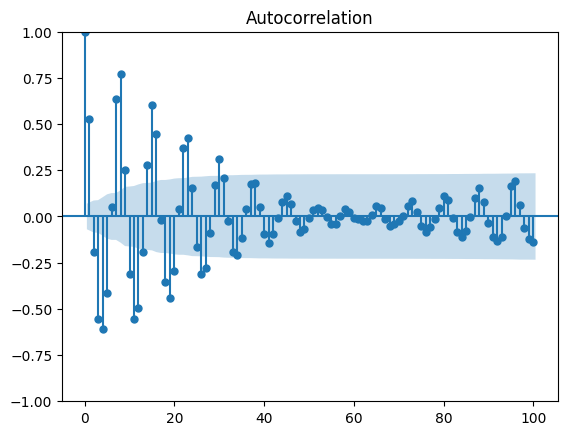

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(y_train_scaled, lags=100)
plt.show()

# Tune p 

In [14]:
p_values = [5, 10, 15, 20, 25, 30, 35, 40]
n_runs = 5
p_means = []
p_stds = []

for p_cand in p_values:
    run_scores = []

    X_tr, T_tr = past_windows_parameter(y_train_scaled, p_cand)
    X_v, T_v   = past_windows_parameter(y_val_tune_scaled, p_cand)

    X_tr_t = torch.tensor(X_tr, dtype=torch.float32).unsqueeze(-1)
    T_tr_t = torch.tensor(T_tr, dtype=torch.float32)
    X_v_t  = torch.tensor(X_v, dtype=torch.float32).unsqueeze(-1)
    T_v_t  = torch.tensor(T_v, dtype=torch.float32)

    loader = DataLoader(TensorDataset(X_tr_t, T_tr_t), batch_size=32, shuffle=True)

    for run in range(n_runs):
        torch.manual_seed(12 + run)

        model = LSTM(hidden_size=64)
        opt = torch.optim.Adam(model.parameters(), lr=1e-3)
        loss_fn = nn.MSELoss()

        n_epochs = 200
        for _ in range(n_epochs):
            model.train()
            for xb, tb in loader:
                opt.zero_grad()
                loss_fn(model(xb), tb).backward()
                opt.step()

        model.eval()
        with torch.no_grad():
            val_mse = loss_fn(model(X_v_t), T_v_t).item()

        run_scores.append(val_mse)

    mean_mse = np.mean(run_scores)
    std_mse  = np.std(run_scores)

    p_means.append(mean_mse)
    p_stds.append(std_mse)

    print(f"p={p_cand:3d}  mean={mean_mse:.6f}  std={std_mse:.6f}")

best_p = p_values[np.argmin(p_means)]
print(f"\nBest p: {best_p}")

p=  5  mean=0.003150  std=0.001525
p= 10  mean=0.001807  std=0.000965
p= 15  mean=0.001541  std=0.000707
p= 20  mean=0.000922  std=0.000337
p= 25  mean=0.002096  std=0.001227
p= 30  mean=0.001231  std=0.000522
p= 35  mean=0.000925  std=0.000144
p= 40  mean=0.001481  std=0.000995

Best p: 20


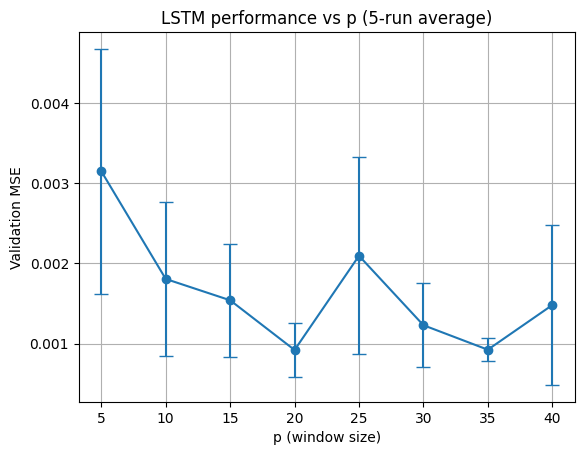

In [15]:
plt.errorbar(p_values, p_means, yerr=p_stds, marker='o', capsize=5)
plt.xlabel("p (window size)")
plt.ylabel("Validation MSE")
plt.title("LSTM performance vs p (5-run average)")
plt.grid(True)
plt.show()

# Tune LSTM model: hidden_size parameter 

In [16]:
hidden_sizes = [16, 32, 64, 128, 256]
n_runs = 5
results_mean = []
results_std = []

X_tr, T_tr = past_windows_parameter(y_train_scaled, best_p)
X_v, T_v   = past_windows_parameter(y_val_tune_scaled, best_p)

X_tr_t = torch.tensor(X_tr, dtype=torch.float32).unsqueeze(-1)
T_tr_t = torch.tensor(T_tr, dtype=torch.float32)
X_v_t  = torch.tensor(X_v, dtype=torch.float32).unsqueeze(-1)
T_v_t  = torch.tensor(T_v, dtype=torch.float32)

loader = DataLoader(TensorDataset(X_tr_t, T_tr_t), batch_size=32, shuffle=True)

for h in hidden_sizes:
    run_scores = []

    for run in range(n_runs):
        torch.manual_seed(12 + run)

        model = LSTM(hidden_size=h)
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
        loss_fn = nn.MSELoss()

        n_epochs = 200
        for _ in range(n_epochs):
            model.train()
            for xb, tb in loader:
                optimizer.zero_grad()
                loss = loss_fn(model(xb), tb)
                loss.backward()
                optimizer.step()

        model.eval()
        with torch.no_grad():
            val_mse = loss_fn(model(X_v_t), T_v_t).item()

        run_scores.append(val_mse)

    mean_score = np.mean(run_scores)
    std_score = np.std(run_scores)

    results_mean.append(mean_score)
    results_std.append(std_score)
    print(f"hidden_size={h} -> val MSE={val_mse:.6f} (mean={results_mean[-1]:.6f}, std={results_std[-1]:.6f})")

best_h = hidden_sizes[np.argmin(results_mean)]
print(f"\nBest hidden size: {best_h}")

hidden_size=16 -> val MSE=0.001394 (mean=0.001233, std=0.000322)
hidden_size=32 -> val MSE=0.001131 (mean=0.000982, std=0.000269)
hidden_size=64 -> val MSE=0.000734 (mean=0.000922, std=0.000337)
hidden_size=128 -> val MSE=0.000566 (mean=0.000744, std=0.000219)
hidden_size=256 -> val MSE=0.001982 (mean=0.001543, std=0.000757)

Best hidden size: 128


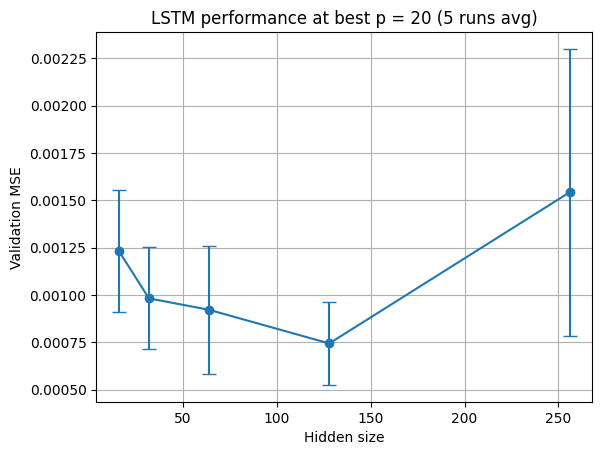

In [17]:
plt.errorbar(hidden_sizes, results_mean, yerr=results_std, marker='o', capsize=5)
plt.xlabel("Hidden size")
plt.ylabel("Validation MSE")
plt.title(f"LSTM performance at best p = {best_p} (5 runs avg)")
plt.grid(True)
plt.show()

# Retrain with optimal p and hidden_size


Epoch 50/200  train=0.0143
Epoch 100/200  train=0.0076
Epoch 150/200  train=0.0174
Epoch 200/200  train=0.0043


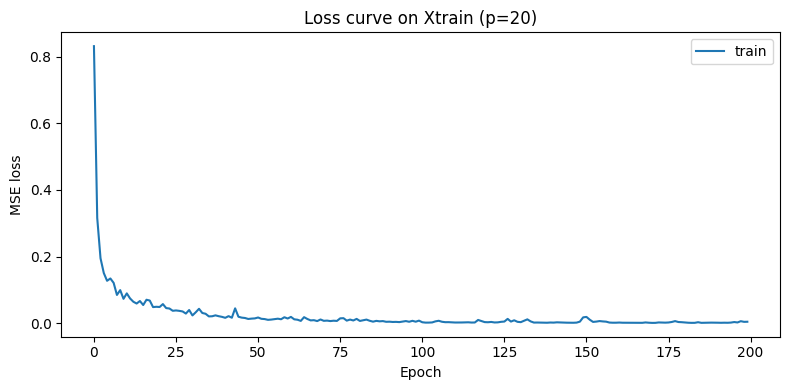

In [10]:
# These values are hardcoded as they where the best in tuning, and there is no need to rerun again especially given the runtime.
p = 20
hidden_size = 128

y_train_final = y
y_train_final_scaled = (y_train_final - mu) / sigma

X_train_final, T_train_final = past_windows_parameter(y_train_final_scaled, p)

X_train_final_tensor = torch.tensor(X_train_final, dtype=torch.float32).unsqueeze(-1) # unsqueeze to add feature dimension for LSTM (shape: [num_samples, p, 1])
T_train_final_tensor = torch.tensor(T_train_final, dtype=torch.float32)

train_loader = DataLoader(TensorDataset(X_train_final_tensor, T_train_final_tensor), batch_size=32, shuffle=True)

model = LSTM(hidden_size=hidden_size)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

n_epochs = 200
train_losses = []

for epoch in range(n_epochs):
    model.train()
    batch_losses = []
    for X_batch, T_batch in train_loader:
        optimizer.zero_grad()
        loss = loss_fn(model(X_batch), T_batch)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())
    train_losses.append(np.mean(batch_losses))

    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1}/{n_epochs}  train={train_losses[-1]:.4f}")

# loss curve
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="train")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title(f"Loss curve on Xtrain (p={p})")
plt.legend()
plt.tight_layout()
plt.show()


# Recursive 200-step prediction

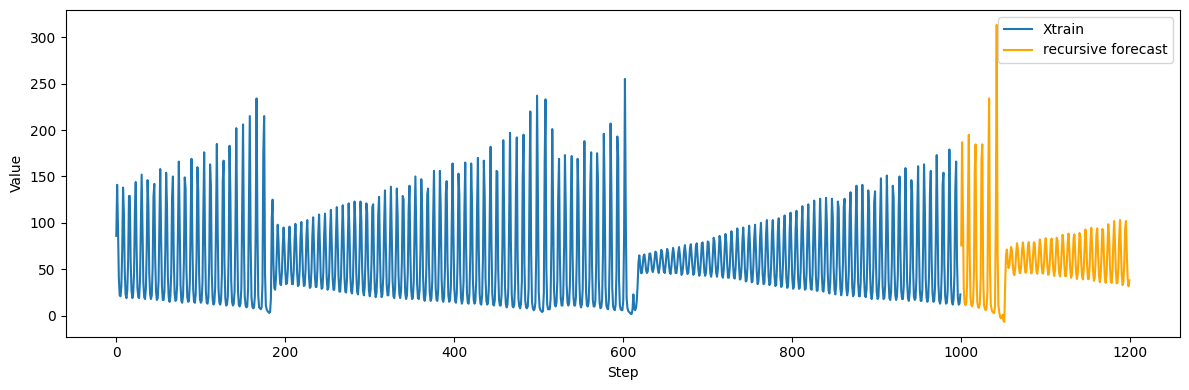

In [11]:
window = list(y_train_final_scaled[-p:])

model.eval()
recursive_preds_scaled = []

with torch.no_grad():
    for _ in range(200):
        x = torch.tensor(window[-p:], dtype=torch.float32).unsqueeze(0).unsqueeze(-1) # shape: [1, p, 1] -> batch size of 1, sequence length of p, and 1 feature
        next_val = model(x).item()
        recursive_preds_scaled.append(next_val)
        window.append(next_val)

recursive_preds = np.array(recursive_preds_scaled) * sigma + mu

plt.figure(figsize=(12, 4))
plt.plot(range(len(y_train_final)), y_train_final, label="Xtrain")
plt.plot(range(len(y_train_final), len(y_train_final) + 200), recursive_preds, label="recursive forecast", color="orange")
plt.xlabel("Step")
plt.ylabel("Value")
plt.legend()
plt.tight_layout()
plt.show()


# run on test set

Test Recursive 200: step MSE: 2134.0325
Test Recursive 200: step MAE: 30.3355


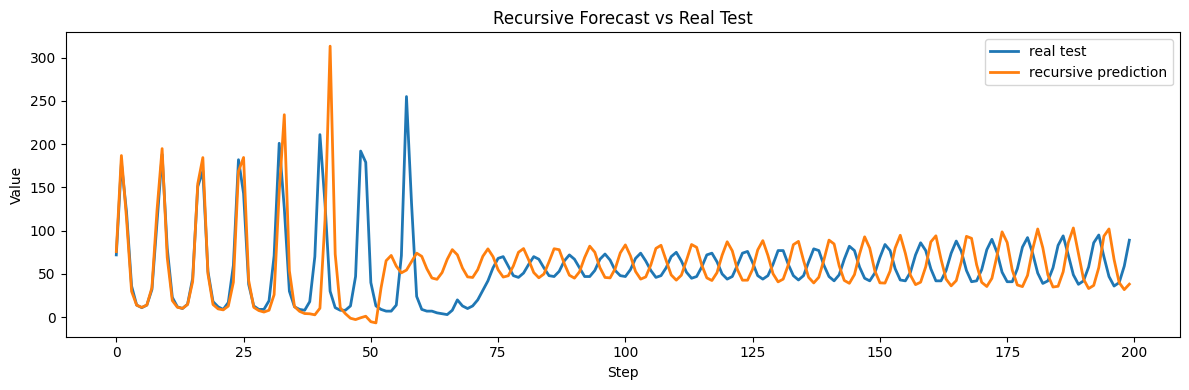

In [ ]:
# evaluate recursive forecast on test set

# Load test data 
mat_test = scipy.io.loadmat("Xtest.mat")
y_test = mat_test["Xtest"].squeeze().astype(np.float32)

# Prepare recursive rollout from end of Xtrain
y_train_scaled = (y - mu) / sigma
window = list(y_train_scaled[-p:])

horizon = min(200, len(y_test))
recursive_preds_scaled = []

model.eval()
with torch.no_grad():
    for _ in range(horizon):
        x = torch.tensor(window[-p:], dtype=torch.float32).unsqueeze(0).unsqueeze(-1) # Squeeze to get the correct shape for LSTM
        next_val = model(x).item()
        recursive_preds_scaled.append(next_val)
        window.append(next_val)

recursive_preds = np.array(recursive_preds_scaled, dtype=np.float32) * sigma + mu
y_true = y_test[:horizon]

# Metrics
mse = np.mean((recursive_preds - y_true) ** 2)
mae = np.mean(np.abs(recursive_preds - y_true))
print(f"Test Recursive {horizon}: step MSE: {mse:.4f}")
print(f"Test Recursive {horizon}: step MAE: {mae:.4f}")

# Plot predicted vs real test values
plt.figure(figsize=(12, 4))
plt.plot(y_true, label="real test", linewidth=2)
plt.plot(recursive_preds, label="recursive prediction", linewidth=2)
plt.xlabel("Step")
plt.ylabel("Value")
plt.title(f"Recursive Forecast vs Real Test")
plt.legend()
plt.tight_layout()
plt.show()
